# Data Cleaning Notebook

In [79]:
# install packages if necessary
%pip install pandas geopandas matplotlib plotnine

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 27.3 MB/s eta 0:00:00 0:00:01

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip3.10 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [34]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon
import matplotlib.pyplot as plt
import zipfile

## The `load_data()` function

- Loads in city data, the [geojson file](https://data.sfgov.org/Geographic-Locations-and-Boundaries/Bay-Area-County-Polygons/wamw-vt4s/data_preview), and crash data
- Converts data to have valid coordinates
- Returns all files

In [16]:
def load_data(stop_path, geo_path, crash_path):
    
    # unzip stop and crash data
    with zipfile.ZipFile(stop_path) as z:
        csv_file = [f for f in z.namelist() if f.endswith(".csv")][0]
        df = pd.read_csv(z.open(csv_file))
    with zipfile.ZipFile(crash_path) as z:
        csv_file = [f for f in z.namelist() if f.endswith(".csv")][0]
        crash_df = pd.read_csv(z.open(csv_file))
    

    # get boundaries of city 
    city_df = gpd.read_file(geo_path)
    
    # get locations of all stops, crashes from the city's dataset
    stops_df = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lng"], df["lat"]),
        crs="EPSG:4326"
    )
    crash_df = gpd.GeoDataFrame(
        crash_df,
        geometry=gpd.points_from_xy(crash_df["tb_longitude"], crash_df["tb_latitude"]),
        crs="EPSG:4326"
    )
    
    # Print coordinate reference system to verify correct locations
    print("Shapefile CRS:", city_df.crs)
    print("Police Stop Data CRS:", stops_df.crs)
    print("Collision Data CRS:", crash_df.crs)
    
    return city_df, stops_df, crash_df

1. We manually add in the pathname for the Bay Area counties <font color='red'>(source?)</font> to see the extent of counties local to San Francisco. 
2. We also add the pathname for the [Stanford Open Policing project data](https://github.com/stanford-policylab/opp/blob/master/data_readme.md) and [San Francisco Traffic Crash dataset](https://data.sfgov.org/Public-Safety/Traffic-Crashes-Resulting-in-Injury/ubvf-ztfx/about_data) to obtain coordinates where stops and crashes occurred.

*Loading this data will assist us in determining if the coordinates logged in the Stanford Open Policing project data have been logged improperly or are irrelevant to our analyses.*

In [17]:
# change path names based on city/dataset
stop_df_path = r"../data/sf_police_stops_raw.csv.zip"
geo_path = r"../data/Bay_Area_County_Polygons.geojson"
crash_df_path = r"../data/collisions_raw.csv.zip"

# load and view example data
city_boundaries, stops_df, crash_df = load_data(stop_df_path, geo_path, crash_df_path)

city_boundaries.head()
stops_df.head()
crash_df.head()


/var/folders/6l/_5f2v6_x5hj1cd_lrwrm8k9r0000gn/T/ipykernel_87768/1506488797.py:6: DtypeWarning:

Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.



Shapefile CRS: EPSG:4326
Police Stop Data CRS: EPSG:4326
Collision Data CRS: EPSG:4326


,unique_id,cnn_intrsctn_fkey,cnn_sgmt_fkey,case_id_pkey,tb_latitude,tb_longitude,geocode_source,geocode_location,collision_datetime,collision_date,...,party2_dir_of_travel,party2_move_pre_acc,point,data_as_of,data_updated_at,data_loaded_at,analysis_neighborhood,supervisor_district,police_district,geometry
0,8099,22339000,10611201.0,2917572,37.747784,-122.444159,SFPD-CROSSROADS,CITY STREET,2006 Dec 01 12:51:00 AM,2006 December 01,...,West,Not Stated,POINT (-122.444158744 37.747783889),2006 Dec 01 12:00:00 AM,2023 Apr 26 12:00:00 AM,2025 Dec 30 10:40:20 AM,Twin Peaks,8.0,MISSION,POINT (-122.44416 37.74778)
1,601,20454000,NaN,2917560,37.722035,-122.393172,SFPD-CROSSROADS,CITY STREET,2006 Dec 01 02:20:00 AM,2006 December 01,...,East,Proceeding Straight,POINT (-122.393171958 37.722034717),2006 Dec 01 12:00:00 AM,2023 Apr 26 12:00:00 AM,2025 Dec 30 10:40:20 AM,Bayview Hunters Point,10.0,BAYVIEW,POINT (-122.39317 37.72203)
2,23156,24583000,170000.0,2945603,37.783463,-122.398527,SFPD-CROSSROADS,CITY STREET,2006 Dec 01 06:22:00 AM,2006 December 01,...,North,Proceeding Straight,POINT (-122.398526901 37.783463366),2006 Dec 01 12:00:00 AM,2023 Apr 26 12:00:00 AM,2025 Dec 30 10:40:20 AM,South of Market,6.0,SOUTHERN,POINT (-122.39853 37.78346)
3,15409,24264000,5671000.0,2922344,37.777384,-122.407035,SFPD-CROSSROADS,CITY STREET,2006 Dec 01 08:25:00 AM,2006 December 01,...,East,Proceeding Straight,POINT (-122.407034911 37.777383709),2006 Dec 01 12:00:00 AM,2023 Apr 26 12:00:00 AM,2025 Dec 30 10:40:20 AM,South of Market,6.0,SOUTHERN,POINT (-122.40703 37.77738)
4,3043,20961000,11908000.0,2917580,37.728803,-122.416918,SFPD-CROSSROADS,CITY STREET,2006 Dec 01 11:41:00 AM,2006 December 01,...,West,Proceeding Straight,POINT (-122.416917976 37.728803467),2006 Dec 01 12:00:00 AM,2023 Apr 26 12:00:00 AM,2025 Dec 30 10:40:20 AM,Portola,9.0,BAYVIEW,POINT (-122.41692 37.7288)


## Visualizing Raw Data Before Preprocessing

Before making any changes to the data, we want to see what it looks like to determine what preprocessing steps are necessary for our geospatial data processing pipeline. 

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
import json
import plotnine
from plotnine import *
from plotnine.data import *
import plotly.io as pio
pio.renderers.default = "browser"


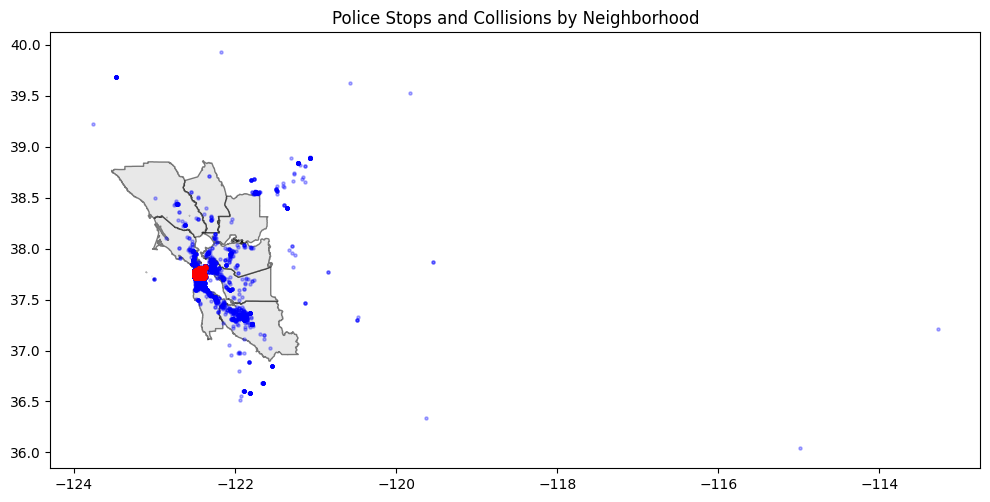

In [20]:
# Plot
fig, ax = plt.subplots(figsize=(12, 10))
# plot bay area county boundaries
city_boundaries.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.5)
# color county=='San Francisco' in city_boundaries a different color

# add stops and collisions
stops_df.plot(ax=ax, color='blue', markersize=5, alpha=0.3)
crash_df.plot(ax=ax, color='red', markersize=5, alpha=0.3)
plt.title("Police Stops and Collisions by Neighborhood")
plt.show()

We can see that there are several coordinates outside of the extent of San Francisco County. 
This leads us to believe these points have been recorded incorrectly, or that there are points  and should be removed from data before modeling. 

## The `fix_coordinates()` function (Preprocess Location)

- Takes in the stop dataset and the city boundaries
- Calculates the bounds of the city
- Filters out points in the stop dataset that aren't within the city boundaries
- Returns a cleaned dataset

Since we are only interested in San Francisco County, we add it to our counties of interest in order to filter out data from other counties. 

In [51]:
# filter city to county of interest
counties_of_interest = ["San Francisco"]

# get number of coordinates within bounds
city_filtered = city_boundaries[city_boundaries['county'].isin(counties_of_interest)]
print("Total points:", len(stops_df))

min_x = city_filtered.total_bounds[0]
max_x = city_filtered.total_bounds[2]
min_y = city_filtered.total_bounds[1]
max_y = city_filtered.total_bounds[3]

print(f"Longitude: {min_x}, {max_x}\nLatitude: {min_y}, {max_y}")


Total points: 905070
Longitude: -123.10802700119842, -122.32768100246903
Latitude: 37.69306499862042, 37.863425998396984


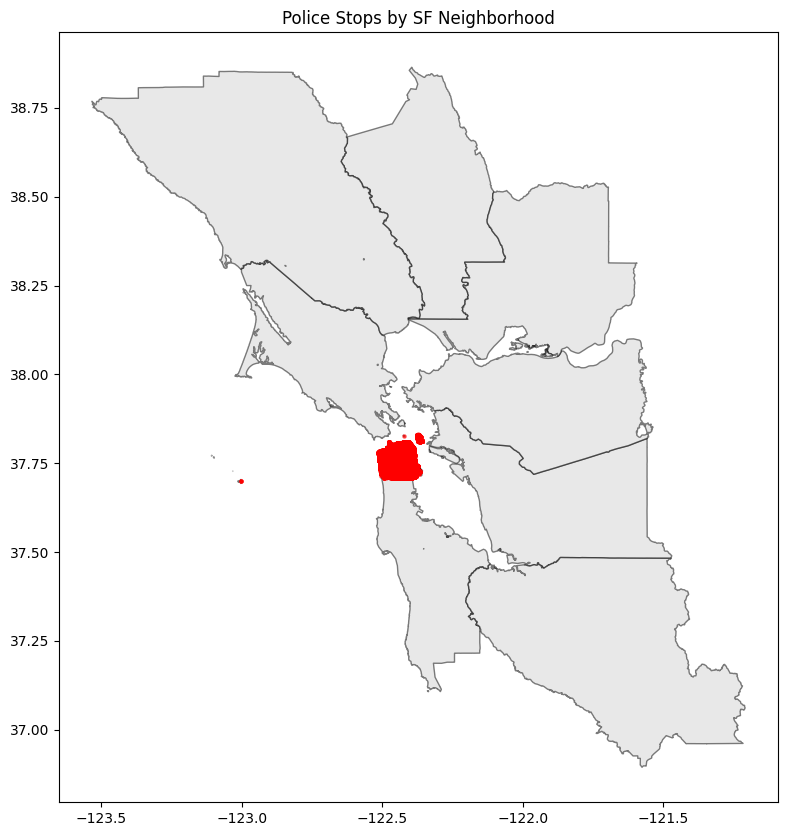

In [71]:
def fix_coordinates(stop_df, city_boundaries, counties_of_interest):

    # only keep data within relevant counties
    city_boundaries = city_boundaries[city_boundaries['county'].isin(counties_of_interest)]
    
    # filter points to within bounaries of county polygon
    stops_clean = gpd.sjoin(stops_df, city_boundaries, predicate="within")
     
    return stops_clean

stops_clean = fix_coordinates(stops_df, city_boundaries, counties_of_interest)

# Now plot with clean data
fig, ax = plt.subplots(figsize=(12, 10))
city_boundaries.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.5)
stops_clean.plot(ax=ax, color='red', markersize=5, alpha=0.6)
plt.title("Police Stops by SF Neighborhood")
plt.show()   

## Preprocess Non Location Variables

In [72]:
# View number of outcomes for each variable of intreset
variables = ['district', 'outcome', 'subject_race', 'subject_sex', 'type', 'reason_for_stop', 'raw_search_vehicle_description', 'raw_result_of_contact_description']

for v in variables:
    print(stops_clean[v].value_counts(normalize=True, dropna=False))

district
H      0.128050
I      0.119772
B      0.117249
C      0.104721
D      0.097407
G      0.094671
E      0.081829
A      0.077421
F      0.068414
NaN    0.057788
J      0.051183
K      0.000863
S      0.000416
T      0.000217
Name: proportion, dtype: float64
outcome
citation    0.697906
warning     0.271646
NaN         0.017280
arrest      0.013168
Name: proportion, dtype: float64
subject_race
white                     0.412096
asian/pacific islander    0.174033
black                     0.167919
hispanic                  0.127830
other                     0.118121
Name: proportion, dtype: float64
subject_sex
male      0.706257
female    0.293743
Name: proportion, dtype: float64
type
vehicular    1.0
Name: proportion, dtype: float64
reason_for_stop
Moving Violation                                                                                                                                                                            0.622566
Mechanical or Non-Moving Violation (V

Based on tabling, the following is suggested:
*  Only keep following for raw vehicle description: 'Vehicle Inventory, Positive Result', 'Vehicle Inventory, Negative Result', 'Searched as a result of Probation or Parole Condition', 'Search without Consent, Positive Result', 'Search without Consent, Negative Result', 'Search with Consent, Positive Result', 'Search with Consent, Negative Result', 'Search Incident to Arrest, Positive Result', 'Search Incident to Arrest, Negative Result', 'No Search'
*  Only keep following for reason for stop: 'Traffic Collision', 'Moving Violation', 'MPC Violation', 'DUI Check', 'BOLO/APB/Warrant', 'Assistance to Motorist'

Note the raw vehicle description helps dervive search outcome (based on if it's postive or negative outcome)

In [ ]:
# Filter out values in raw vehicle description
raw_vehicle_desc_keep = ['Vehicle Inventory, Positive Result', 'Vehicle Inventory, Negative Result', 'Searched as a result of Probation or Parole Condition', 'Search without Consent, Positive Result', 'Search without Consent, Negative Result', 'Search with Consent, Positive Result', 'Search with Consent, Negative Result', 'Search Incident to Arrest, Positive Result', 'Search Incident to Arrest, Negative Result', 'No Search']
stops_clean = stops_clean[stops_clean['raw_search_vehicle_description'].isin(raw_vehicle_desc_keep)]

raw_reason_for_stop = ['Traffic Collision', 'Moving Violation', 'MPC Violation', 'DUI Check', 'BOLO/APB/Warrant', 'Assistance to Motorist']
stops_clean = stops_clean[stops_clean['reason_for_stop'].isin(raw_reason_for_stop)]

Now lets filter out NA in  'subject_age', 'time', 'district'

In [74]:
stops_clean = stops_clean.dropna(subset = ['subject_age', 'time', 'district'])

Looking at stops over time:

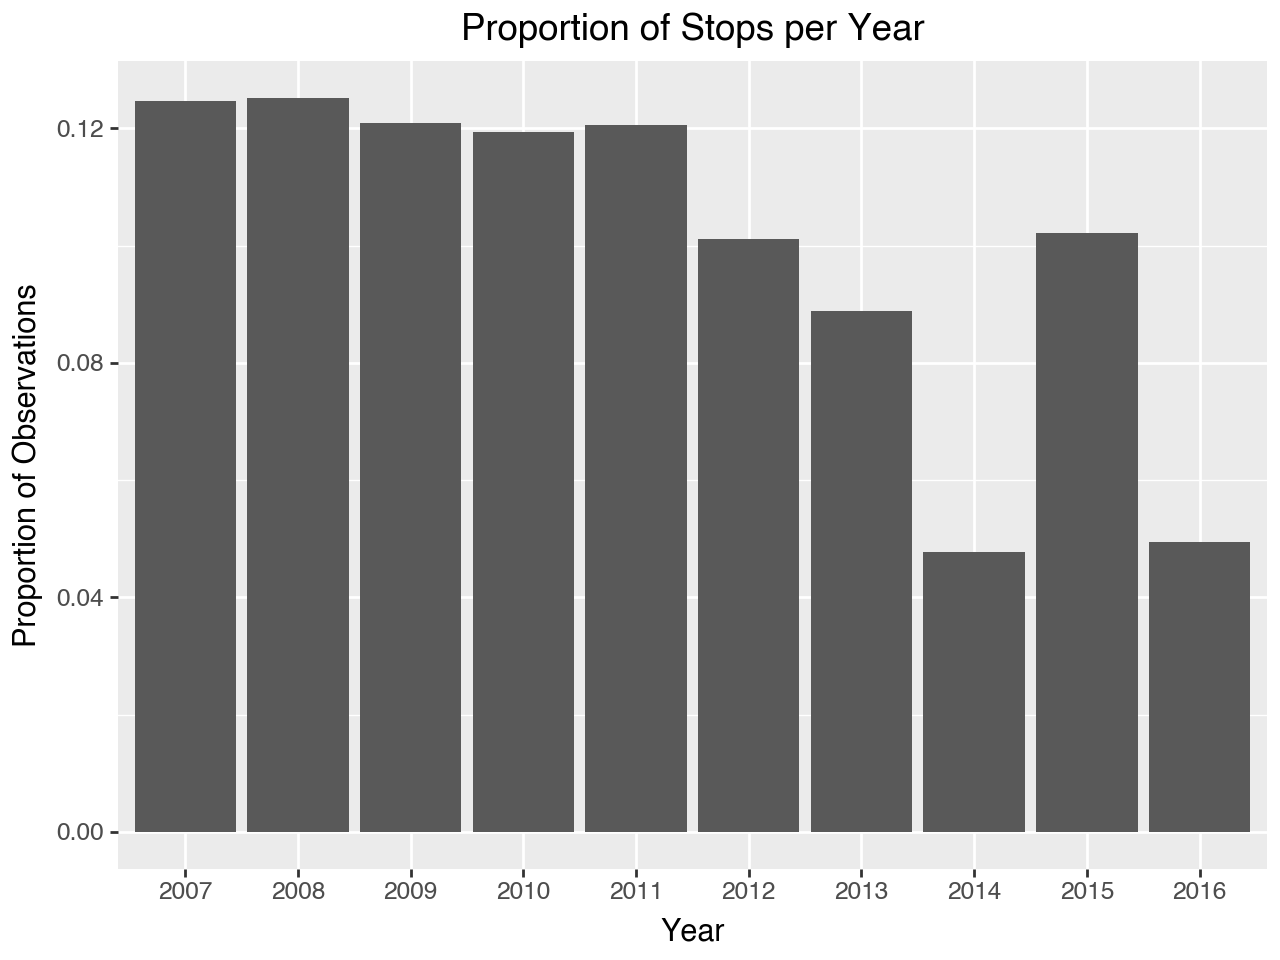

In [ ]:
# get proportion of stops across years
stops_clean['date'] = pd.to_datetime(stops_clean['date'])
stops_clean['year'] = stops_clean['date'].dt.year
year_counts = (
    stops_clean['year']
    .value_counts()
    .sort_index()
    .reset_index()
)
year_counts.columns = ['year', 'count']
year_counts['prop'] = year_counts['count'] / year_counts['count'].sum()

(
    ggplot(year_counts, aes(x='factor(year)', y='count')) +
    geom_col() +
    labs(
        x="Year",
        y="Stops",
        title="Number of Stops per Year"
    )
)

(
    ggplot(year_counts, aes(x='factor(year)', y='prop')) +
    geom_col() +
    labs(
        x="Year",
        y="Proportion of Observations",
        title="Proportion of Stops per Year"
    )
)

In [ ]:
# filter dataset to 2012 onward
stops_clean = stops_clean[stops_clean['year'] >= 2012]

,raw_row_number,date,time,location,lat,lng,district,subject_age,subject_race,subject_sex,...,geometry,index_right,:id,:version,:created_at,:updated_at,objectid,fipsstco,county,year
563369,531403,2012-01-01,10:00:00,STOCKTON & SUTTER,37.789432,-122.406993,A,38.0,asian/pacific islander,female,...,POINT (-122.40699 37.78943),4,row-hv7k-4wq5-gcrn,rv-uicg-9edy~2szt,2025-02-03 19:15:36.343000+00:00,2025-02-03 19:15:36.343000+00:00,5,06075,San Francisco,2012
563370,531402,2012-01-01,10:00:00,MARKET & 6TH ST,37.782211,-122.410356,B,34.0,white,male,...,POINT (-122.41036 37.78221),4,row-hv7k-4wq5-gcrn,rv-uicg-9edy~2szt,2025-02-03 19:15:36.343000+00:00,2025-02-03 19:15:36.343000+00:00,5,06075,San Francisco,2012
563371,531404,2012-01-01,10:05:00,6TH/MARKET,37.782211,-122.410356,B,41.0,asian/pacific islander,male,...,POINT (-122.41036 37.78221),4,row-hv7k-4wq5-gcrn,rv-uicg-9edy~2szt,2025-02-03 19:15:36.343000+00:00,2025-02-03 19:15:36.343000+00:00,5,06075,San Francisco,2012
563373,531364,2012-01-01,01:01:00,MOSCOW ST & PERSIA AVE,37.719716,-122.428841,H,47.0,other,male,...,POINT (-122.42884 37.71972),4,row-hv7k-4wq5-gcrn,rv-uicg-9edy~2szt,2025-02-03 19:15:36.343000+00:00,2025-02-03 19:15:36.343000+00:00,5,06075,San Francisco,2012
563376,531407,2012-01-01,10:25:00,NORIEGA STREET AND 39TH AVENUE,37.753304,-122.497927,I,26.0,white,female,...,POINT (-122.49793 37.7533),4,row-hv7k-4wq5-gcrn,rv-uicg-9edy~2szt,2025-02-03 19:15:36.343000+00:00,2025-02-03 19:15:36.343000+00:00,5,06075,San Francisco,2012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886036,768451,2016-06-30,09:15:00,GOLDEN GATE & JONES,37.782084,-122.412246,J,35.0,asian/pacific islander,male,...,POINT (-122.41225 37.78208),4,row-hv7k-4wq5-gcrn,rv-uicg-9edy~2szt,2025-02-03 19:15:36.343000+00:00,2025-02-03 19:15:36.343000+00:00,5,06075,San Francisco,2016
886037,768452,2016-06-30,09:24:00,JONES & MCALLISTER,37.781168,-122.412058,J,47.0,hispanic,female,...,POINT (-122.41206 37.78117),4,row-hv7k-4wq5-gcrn,rv-uicg-9edy~2szt,2025-02-03 19:15:36.343000+00:00,2025-02-03 19:15:36.343000+00:00,5,06075,San Francisco,2016
886038,768453,2016-06-30,09:34:00,GOLDEN GATE & HYDE,37.781668,-122.415524,J,55.0,white,female,...,POINT (-122.41552 37.78167),4,row-hv7k-4wq5-gcrn,rv-uicg-9edy~2szt,2025-02-03 19:15:36.343000+00:00,2025-02-03 19:15:36.343000+00:00,5,06075,San Francisco,2016
886039,768454,2016-06-30,09:50:00,11TH ST. & MARKET ST.,37.775238,-122.418444,J,36.0,asian/pacific islander,male,...,POINT (-122.41844 37.77524),4,row-hv7k-4wq5-gcrn,rv-uicg-9edy~2szt,2025-02-03 19:15:36.343000+00:00,2025-02-03 19:15:36.343000+00:00,5,06075,San Francisco,2016


In [124]:
# Plot heatmap to show distribution of crashes and collisions from raw data
geojson = city_boundaries.__geo_interface__

# plot baselayer
fig = px.choropleth_map(
    city_boundaries,
    geojson=geojson,
    locations=city_boundaries.index,
    color_discrete_sequence=["lightgray"],
    map_style="carto-positron",
    zoom=8,
    center={"lat": 37.77, "lon": -122.42},
    opacity=0.4
)

# Police stop density
fig.add_trace(
    go.Densitymap(
        lat=stops_clean.geometry.y,
        lon=stops_clean.geometry.x,
        radius=10, 
        opacity=0.6,
        hoverinfo="skip",
        showscale=False,
        name="Stops"
    )
)

fig.update_layout(
    title="Police Stops and Collisions Density",
    hovermode=False,
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.show()

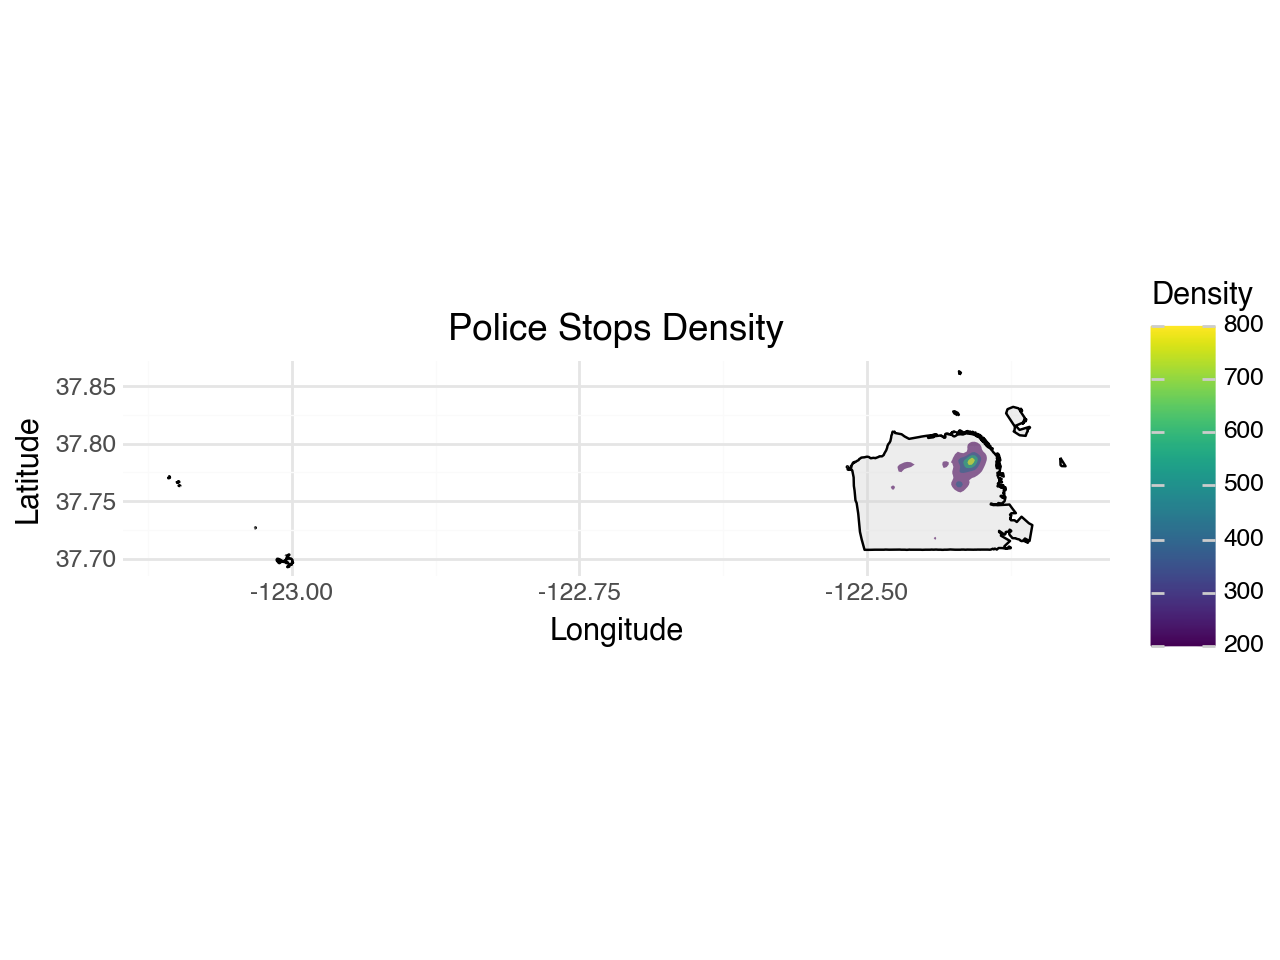

In [119]:
stops_clean = stops_clean.to_crs(city_filtered.crs)
stops_clean["lon"] = stops_clean.geometry.x
stops_clean["lat"] = stops_clean.geometry.y

(
    ggplot() +
    # City boundary (base layer)
    geom_map(
        city_filtered,
        fill="lightgray",
        color="black",
        alpha=0.4
    ) +
    # Density heatmap layer
    stat_density_2d(
        stops_clean,
        aes(x="lon", y="lat", fill="..level.."),
        geom="polygon",
        alpha=0.6,
        contour=True
    ) +
    scale_fill_cmap(name="Density", cmap_name="viridis") +
    labs(
        title="Police Stops Density",
        x="Longitude",
        y="Latitude"
    ) +
    coord_equal() +
    theme_minimal()
)

### Processing the Crash Dataset

- keep processing separate or together?
- clean out crashes in similar manner

In [ ]:
# see what data looks like when outcome = NA (none of warning, citation, arrest)
